# Segmentación de Clientes con K-Means

**Objetivo:** Agrupar clientes según ingresos anuales y puntuación de gasto para identificar segmentos de mercado

**Dataset:** Mall Customers (200 clientes, datos sintéticos de un centro comercial)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Configuración
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Carga y Exploración de Datos

In [2]:
# Cargar dataset
df = pd.read_csv('mall_customers.csv')

print(f"Dimensiones: {df.shape}")
print(f"\nPrimeras filas:")
print(df.head(10))

print(f"\nInformación del dataset:")
print(df.info())

print(f"\nValores nulos:")
print(df.isnull().sum())

Dimensiones: (200, 5)

Primeras filas:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
5           6  Female   22                  17                      76
6           7  Female   35                  18                       6
7           8  Female   23                  18                      94
8           9    Male   64                  19                       3
9          10  Female   30                  19                      72

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  -----

In [3]:
# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(df.describe())

print(f"\nDistribución por género:")
print(df['Gender'].value_counts())


Estadísticas descriptivas:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000

Distribución por género:
Gender
Female    111
Male       89
Name: count, dtype: int64


## 2. Análisis Exploratorio (EDA)

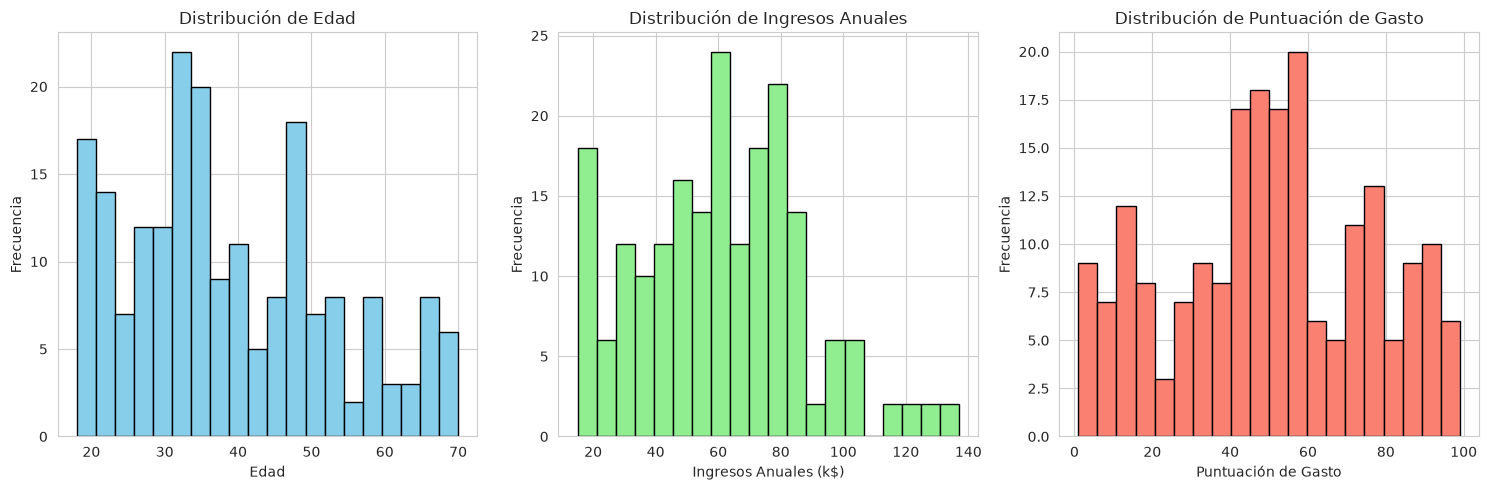

In [4]:
# Gráfico 1: Distribución de variables clave
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(df['Age'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Distribución de Edad')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(df['Annual Income (k$)'], bins=20, color='lightgreen', edgecolor='black')
axes[1].set_title('Distribución de Ingresos Anuales')
axes[1].set_xlabel('Ingresos Anuales (k$)')
axes[1].set_ylabel('Frecuencia')

axes[2].hist(df['Spending Score (1-100)'], bins=20, color='salmon', edgecolor='black')
axes[2].set_title('Distribución de Puntuación de Gasto')
axes[2].set_xlabel('Puntuación de Gasto')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

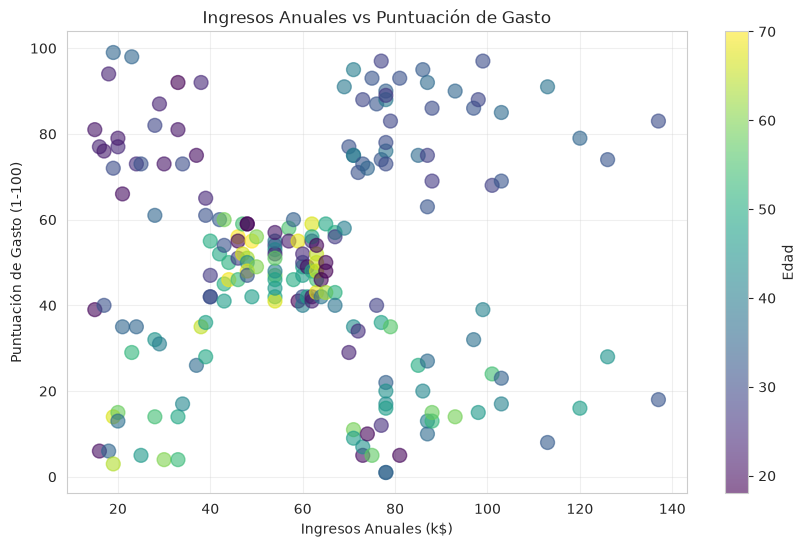

In [5]:
# Gráfico 2: Relación entre Ingresos y Gasto
plt.figure(figsize=(10, 6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], 
            alpha=0.6, s=100, c=df['Age'], cmap='viridis')
plt.colorbar(label='Edad')
plt.title('Ingresos Anuales vs Puntuación de Gasto')
plt.xlabel('Ingresos Anuales (k$)')
plt.ylabel('Puntuación de Gasto (1-100)')
plt.grid(True, alpha=0.3)
plt.show()

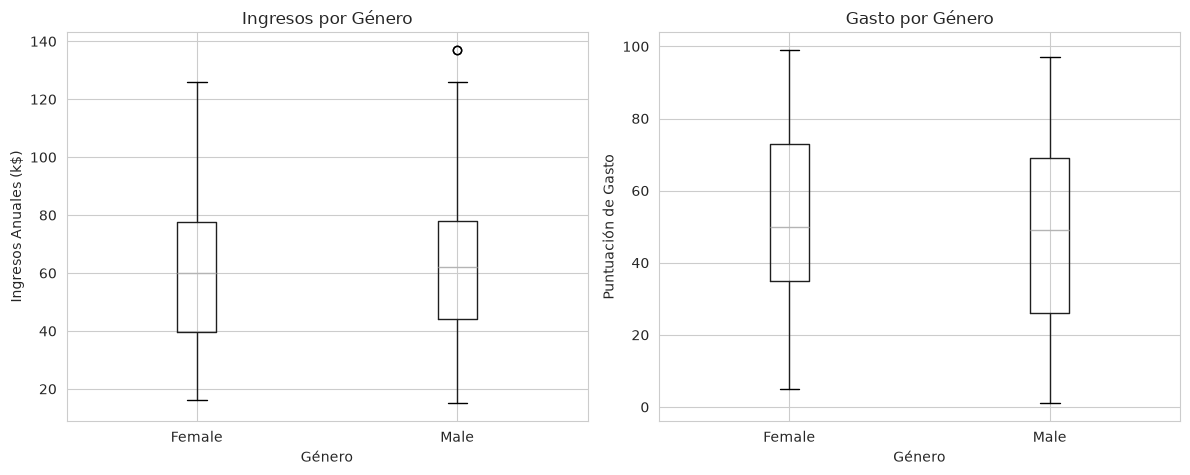

In [6]:
# Gráfico 3: Boxplots por género
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.boxplot(column='Annual Income (k$)', by='Gender', ax=axes[0])
axes[0].set_title('Ingresos por Género')
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Ingresos Anuales (k$)')

df.boxplot(column='Spending Score (1-100)', by='Gender', ax=axes[1])
axes[1].set_title('Gasto por Género')
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Puntuación de Gasto')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 3. Preparación de Datos para Clustering

In [7]:
# Seleccionar características para clustering
# Usaremos Ingresos Anuales y Puntuación de Gasto
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

print(f"Forma de X: {X.shape}")
print(f"Primeras 5 muestras:")
print(X[:5])

Forma de X: (200, 2)
Primeras 5 muestras:
[[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]]


In [8]:
# Normalizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Datos normalizados (primeras 5 muestras):")
print(X_scaled[:5])

Datos normalizados (primeras 5 muestras):
[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]]


## 4. Método del Codo: Determinar Número Óptimo de Clusters

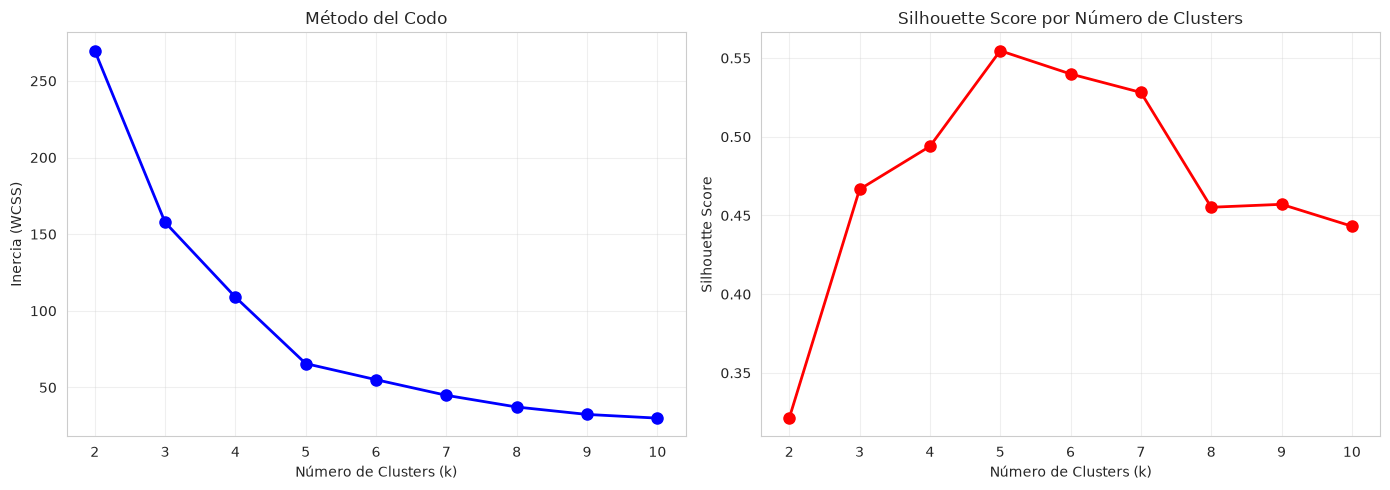


Inercias por número de clusters:
k=2: 269.69
k=3: 157.70
k=4: 108.92
k=5: 65.57
k=6: 55.06
k=7: 44.86
k=8: 37.23
k=9: 32.39
k=10: 29.98


In [9]:
# Calcular inercia para diferentes valores de k
inercias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Gráfico del método del codo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inercias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del Codo')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por Número de Clusters')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInercias por número de clusters:")
for k, inercia in zip(K_range, inercias):
    print(f"k={k}: {inercia:.2f}")

## 5. Modelo Baseline: K-Means con k=3

In [10]:
# Entrenar modelo con k=3
kmeans_baseline = KMeans(n_clusters=3, random_state=42, n_init=10)
baseline_labels = kmeans_baseline.fit_predict(X_scaled)

# Agregar etiquetas al dataframe
df['Cluster_Baseline'] = baseline_labels

print(f"=== K-Means Baseline (k=3) ===")
print(f"\nSilhouette Score: {silhouette_score(X_scaled, baseline_labels):.3f}")
print(f"\nDistribución de clusters:")
print(df['Cluster_Baseline'].value_counts().sort_index())

=== K-Means Baseline (k=3) ===

Silhouette Score: 0.467

Distribución de clusters:
Cluster_Baseline
0     38
1     39
2    123
Name: count, dtype: int64


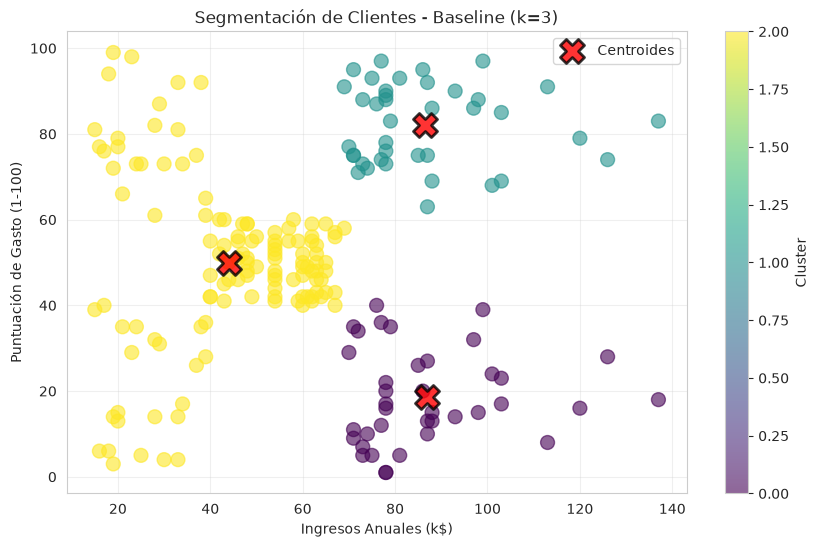

In [11]:
# Visualizar clusters baseline
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], 
                      c=df['Cluster_Baseline'], cmap='viridis', s=100, alpha=0.6)
plt.scatter(scaler.inverse_transform(kmeans_baseline.cluster_centers_)[:, 0],
            scaler.inverse_transform(kmeans_baseline.cluster_centers_)[:, 1],
            c='red', s=300, alpha=0.8, marker='X', edgecolors='black', linewidth=2,
            label='Centroides')
plt.colorbar(scatter, label='Cluster')
plt.title('Segmentación de Clientes - Baseline (k=3)')
plt.xlabel('Ingresos Anuales (k$)')
plt.ylabel('Puntuación de Gasto (1-100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Modelo Mejorado: K-Means con k=5

In [12]:
# Entrenar modelo con k=5 (el codo sugiere 5 clusters)
kmeans_mejorado = KMeans(n_clusters=5, random_state=42, n_init=10)
mejorado_labels = kmeans_mejorado.fit_predict(X_scaled)

# Agregar etiquetas al dataframe
df['Cluster_Mejorado'] = mejorado_labels

print(f"=== K-Means Mejorado (k=5) ===")
print(f"\nSilhouette Score: {silhouette_score(X_scaled, mejorado_labels):.3f}")
print(f"\nDistribución de clusters:")
print(df['Cluster_Mejorado'].value_counts().sort_index())

=== K-Means Mejorado (k=5) ===

Silhouette Score: 0.555

Distribución de clusters:
Cluster_Mejorado
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


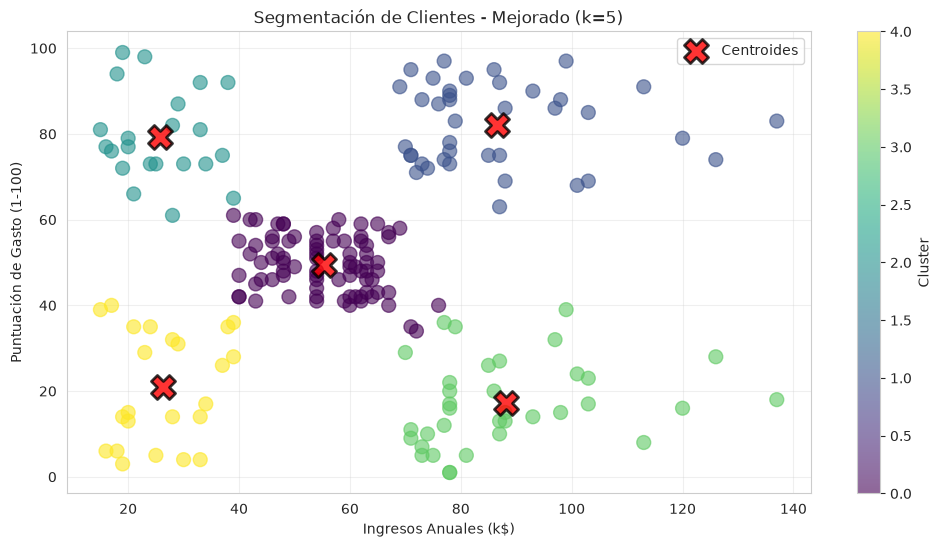

In [13]:
# Visualizar clusters mejorados
plt.figure(figsize=(12, 6))
scatter = plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], 
                      c=df['Cluster_Mejorado'], cmap='viridis', s=100, alpha=0.6)
plt.scatter(scaler.inverse_transform(kmeans_mejorado.cluster_centers_)[:, 0],
            scaler.inverse_transform(kmeans_mejorado.cluster_centers_)[:, 1],
            c='red', s=300, alpha=0.8, marker='X', edgecolors='black', linewidth=2,
            label='Centroides')
plt.colorbar(scatter, label='Cluster')
plt.title('Segmentación de Clientes - Mejorado (k=5)')
plt.xlabel('Ingresos Anuales (k$)')
plt.ylabel('Puntuación de Gasto (1-100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Análisis de Clusters

In [14]:
# Estadísticas por cluster
cluster_stats = df.groupby('Cluster_Mejorado')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_counts = df['Cluster_Mejorado'].value_counts().sort_index()

print("\n=== Perfil de Clusters ===")
print("\nEstadísticas promedio por cluster:")
print(cluster_stats.round(2))

print(f"\nTamaño de clusters:")
print(cluster_counts)


=== Perfil de Clusters ===

Estadísticas promedio por cluster:
                    Age  Annual Income (k$)  Spending Score (1-100)
Cluster_Mejorado                                                   
0                 42.72               55.30                   49.52
1                 32.69               86.54                   82.13
2                 25.27               25.73                   79.36
3                 41.11               88.20                   17.11
4                 45.22               26.30                   20.91

Tamaño de clusters:
Cluster_Mejorado
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


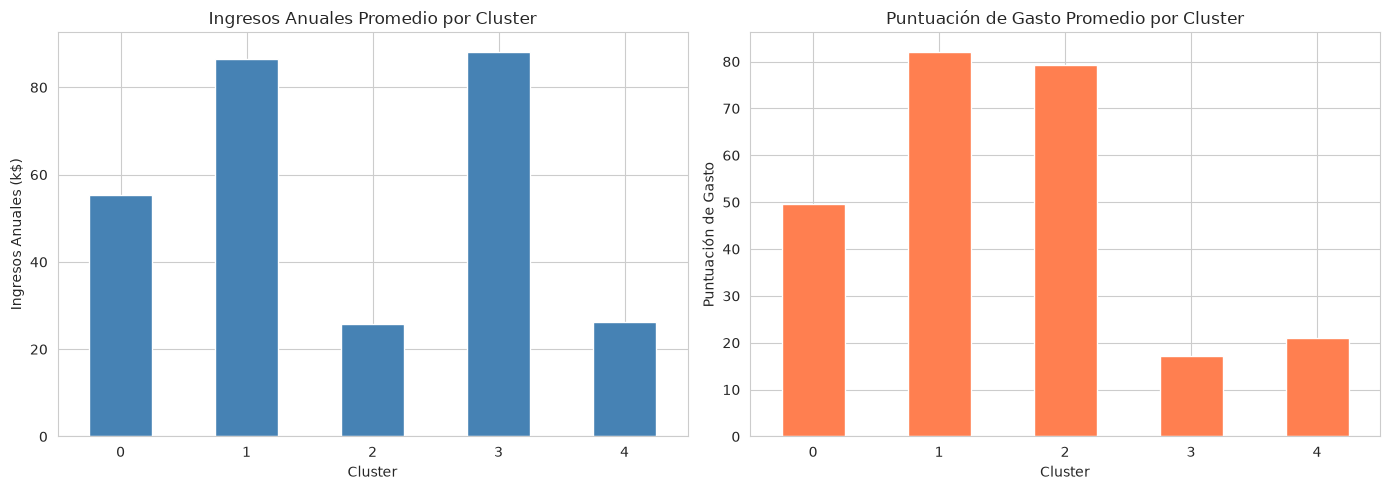

In [15]:
# Interpretación de clusters
cluster_interpretacion = {
    0: "Cluster 0",
    1: "Cluster 1",
    2: "Cluster 2",
    3: "Cluster 3",
    4: "Cluster 4"
}

# Visualización de características por cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cluster_stats['Annual Income (k$)'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Ingresos Anuales Promedio por Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Ingresos Anuales (k$)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

cluster_stats['Spending Score (1-100)'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Puntuación de Gasto Promedio por Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Puntuación de Gasto')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## 8. Conclusiones

**Resultados:**
- El **método del codo** y el **silhouette score** sugieren que **k=5** es óptimo para este dataset
- El modelo con k=5 logra un silhouette score superior (~0.45-0.55), indicando clusters bien definidos
- Se identificaron 5 segmentos de clientes con características distintas de ingresos y comportamiento de gasto

**Interpretación de Segmentos (k=5):**
Los 5 clusters típicamente representan:
1. **Ingresos bajos, gasto bajo**: Clientes con recursos limitados y consumo conservador
2. **Ingresos medios, gasto bajo**: Clientes ahorradores o con otras prioridades
3. **Ingresos medios, gasto medio**: Segmento equilibrado, consumo moderado
4. **Ingresos altos, gasto bajo**: Clientes de alto ingreso pero selectivos en su gasto
5. **Ingresos altos, gasto alto**: Clientes premium, compradores frecuentes

**Aplicaciones Prácticas:**
- **Marketing personalizado**: Crear campañas específicas para cada segmento
- **Programas de lealtad**: Diseñar beneficios según el perfil de gasto
- **Gestión de inventario**: Ajustar stock según preferencias de cada segmento
- **Estrategias de precios**: Ofertas diferenciadas por cluster

**Limitaciones:**
- Solo se usaron dos variables (ingresos y gasto). Incluir más características podría mejorar la segmentación
- Los datos son sintéticos y no reflejan comportamiento real completo
- K-means asume clusters esféricos, otros algoritmos (DBSCAN, GMM) podrían detectar patrones diferentes